## Baseline Experiments

This notebook focuses on testing different experiments on the baseline. Baseline in this project serves similiarly as self-grafting operator baseline in Grafting paper, however we use small defined set of operators instead of randomly initialized operator weights.

setup

In [1]:
from math import ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.capture import ActivationPairs, collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig, OperatorConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.language_model import evaluate_language_model
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import GatedMLPReplacement, fit_operator, fit_ridge_linear
from mlp_replacement.surgery import count_parameters, temporary_replacement

### Single-block Experiments

In [4]:
SEED = 21
TARGET_LAYER = 11

MAX_CALIBRATION_BATCHES = 48
CALIBRATION_BUDGETS = [8, 16, 32, 48]

SWIGLU_WIDTH_RATIOS = [0.25, 0.50, 0.75, 0.90]

LINEAR_RIDGE = 1e-4

In [5]:
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)
data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=MAX_CALIBRATION_BATCHES,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

In [7]:
training_config = OperatorConfig(
    kind='bottleneck_mlp',
    bottleneck_ratio=0.5,
    activation='silu',
    bias=False,
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

In [8]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
block = get_mlp_block(model, TARGET_LAYER)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

In [9]:
loaders = build_data_loaders(
    tokenizer,
    data_config,
    include_recovery=False,
)

Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


In [10]:
capture_kwargs = {
    'device': device,
    'storage_device': 'cpu',
    'storage_dtype': torch.float32,
}
training_pool = collect_module_io(
    model,
    block.path,
    loaders.calibration,
    MAX_CALIBRATION_BATCHES,
    **capture_kwargs,
)
validation_pairs = collect_module_io(
    model,
    block.path,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)

In [11]:
hidden_size = training_pool.hidden_size
original_intermediate_width = int(block.module.up_proj.out_features)
original_parameters = count_parameters(block.module)
tokens_per_batch = data_config.batch_size * data_config.sequence_length

In [12]:
baseline_lm = evaluate_language_model(
    model,
    loaders.model_validation,
    device,
    data_config.num_model_validation_batches,
)

In [13]:
def calibration_prefix(num_batches):
    token_count = num_batches * tokens_per_batch
    return ActivationPairs(
        inputs=training_pool.inputs[:token_count],
        targets=training_pool.targets[:token_count],
    )

In [14]:
def local_row(name, module, pairs, fit=None):
    module = module.to(device)
    metrics = evaluate_operator(
        module,
        validation_pairs,
        device,
        training_config.batch_size,
    )
    epochs = len(fit.history) if fit is not None else 0
    return {
        'operator': name,
        'calibration_tokens': pairs.num_tokens,
        'parameters': count_parameters(module),
        'local_mse': metrics.mse,
        'local_relative_mse': metrics.relative_mse,
        'local_cosine': metrics.cosine_similarity,
        'best_epoch': fit.best_epoch if fit is not None else 0,
        'optimizer_steps': (
            epochs * ceil(pairs.num_tokens / training_config.batch_size)
        ),
    }

In [15]:
def model_metrics(module):
    module = module.to(device)
    with temporary_replacement(model, TARGET_LAYER, module):
        return evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )

### Experiments

#### Compute Budget importance

,operator,calibration_tokens,parameters,local_mse,local_relative_mse,local_cosine,best_epoch,optimizer_steps,calibration_batches
0,linear,2048,4194304,23.940392,15.357863,0.131913,0,0,8
1,affine,2048,4196352,25.801560,16.551811,0.128023,0,0,8
2,swiglu_0.50,2048,25165824,1.303715,0.836339,0.411205,64,64,8
3,linear,4096,4194304,2.102676,1.348876,0.432118,0,0,16
4,affine,4096,4196352,2.104359,1.349955,0.440939,0,0,16
5,swiglu_0.50,4096,25165824,1.153576,0.740024,0.510885,64,128,16
6,linear,8192,4194304,1.268439,0.813709,0.553037,0,0,32
7,affine,8192,4196352,1.268726,0.813893,0.563711,0,0,32
8,swiglu_0.50,8192,25165824,1.036340,0.664816,0.581925,54,228,32
9,linear,12288,4194304,1.091264,0.700050,0.594335,0,0,48


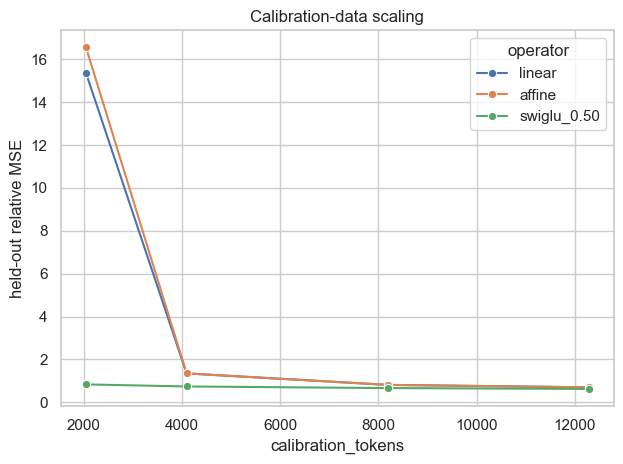

In [16]:
budget_rows = []
fixed_width = round(0.5 * original_intermediate_width)

for num_batches in CALIBRATION_BUDGETS:
    pairs = calibration_prefix(num_batches)
    linear = fit_ridge_linear(
        pairs, ridge=LINEAR_RIDGE, bias=False, device=device
    )
    affine = fit_ridge_linear(
        pairs, ridge=LINEAR_RIDGE, bias=True, device=device
    )
    torch.manual_seed(SEED)
    swiglu_fit = fit_operator(
        GatedMLPReplacement(hidden_size, fixed_width, bias=False),
        pairs,
        validation_pairs,
        training_config,
        device,
    )

    for name, module, fit in [
        ('linear', linear, None),
        ('affine', affine, None),
        ('swiglu_0.50', swiglu_fit.module, swiglu_fit),
    ]:
        row = local_row(name, module, pairs, fit)
        row['calibration_batches'] = num_batches
        budget_rows.append(row)

budget_df = pd.DataFrame(budget_rows)
ax = sns.lineplot(
    data=budget_df,
    x='calibration_tokens',
    y='local_relative_mse',
    hue='operator',
    marker='o',
)
ax.set(
    title='Calibration-data scaling',
    ylabel='held-out relative MSE',
)
plt.tight_layout()
budget_df

#### swiGLU analysis

In [17]:
full_pairs = calibration_prefix(MAX_CALIBRATION_BATCHES)
width_rows = []
reference_rows = []

for name, bias in [('linear', False), ('affine', True)]:
    module = fit_ridge_linear(
        full_pairs, ridge=LINEAR_RIDGE, bias=bias, device=device
    )
    row = local_row(name, module, full_pairs)
    integrated = model_metrics(module)
    row.update({
        'perplexity': integrated.perplexity,
        'delta_perplexity': (
            integrated.perplexity - baseline_lm.perplexity
        ),
    })
    reference_rows.append(row)

for ratio in SWIGLU_WIDTH_RATIOS:
    width = max(1, round(ratio * original_intermediate_width))
    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(hidden_size, width, bias=False),
        full_pairs,
        validation_pairs,
        training_config,
        device,
    )
    row = local_row(f'swiglu_{ratio:.2f}', fit.module, full_pairs, fit)
    integrated = model_metrics(fit.module)
    row.update({
        'width_ratio': ratio,
        'intermediate_width': width,
        'relative_block_parameters': (
            count_parameters(fit.module) / original_parameters
        ),
        'perplexity': integrated.perplexity,
        'delta_perplexity': (
            integrated.perplexity - baseline_lm.perplexity
        ),
    })
    width_rows.append(row)

width_df = pd.DataFrame(width_rows)
reference_df = pd.DataFrame(reference_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='local_relative_mse',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='perplexity',
    marker='o',
    ax=axes[1],
)
for reference in reference_df.itertuples():
    axes[0].axhline(
        reference.local_relative_mse,
        linestyle='--',
        label=reference.operator,
    )
    axes[1].axhline(
        reference.perplexity,
        linestyle='--',
        label=reference.operator,
    )
axes[1].axhline(
    baseline_lm.perplexity,
    color='black',
    linestyle=':',
    label='original MLP',
)
axes[0].set(title='Local approximation', ylabel='held-out relative MSE')
axes[1].set(title='Model quality', ylabel='perplexity')
for axis in axes:
    axis.legend()
plt.tight_layout()
width_df

KeyboardInterrupt: 

In [18]:
len(reference_rows), len(width_rows)

(2, 3)

In [19]:
[row["operator"] for row in width_rows]

['swiglu_0.25', 'swiglu_0.50', 'swiglu_0.75']

### Multi-block Experiments